<a href="https://colab.research.google.com/github/lakshitaaa19/Quantum-classical-classifier/blob/main/Classical_to_Quantumm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

2. Quantum AI Version (Equivalent Starting Code)

Here’s how you would rewrite this setup for a Quantum Machine Learning (QML) workflow — using frameworks such as:

PennyLane (by Xanadu)

Qiskit Machine Learning (by IBM)

TensorFlow Quantum (TFQ) (by Google)

Cirq (for quantum circuits)

Let’s start with a version using TensorFlow Quantum, since your original code uses TensorFlow — this keeps the environment familiar.

In [ ]:
!pip install pennylane pennylane-qiskit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.1/57.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 64.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 934.3/934.3 kB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 67.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 61.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 60.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 58.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 71.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 167.9/167.9 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 377.4/377.4 kB 26.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 82.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.4/54.4 kB 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
%matplotlib inline

In [ ]:
# Classical ML utils (still used for preprocessing / PCA / metrics)
from sklearn.preprocessing import MinMaxScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
import pennylane as qml
print(qml.version())


0.43.1


In [ ]:
import pennylane as qml
print("Installed PennyLane version:", qml.version())

Installed PennyLane version: 0.43.1


In [ ]:
import pennylane as qml
import tensorflow as tf

print("PennyLane version:", qml.version())
print("TensorFlow version:", tf.__version__)


PennyLane version: 0.43.1
TensorFlow version: 2.19.0


In [ ]:
# Snippet 0 — install + load dataset (run first)
!pip install kagglehub pennylane torch scikit-learn xgboost lightgbm catboost --quiet

import os, kagglehub, pandas as pd
dataset_path = kagglehub.dataset_download("prasad22/healthcare-dataset")
# find CSV
csv_file = None
for root, dirs, files in os.walk(dataset_path):
    for f in files:
        if f.endswith(".csv"):
            csv_file = os.path.join(root, f); break
    if csv_file: break
if not csv_file:
    raise FileNotFoundError("Could not find CSV in downloaded dataset folder.")
data = pd.read_csv(csv_file)
print("Loaded:", csv_file, "| shape:", data.shape)
display(data.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 7.6 MB/s eta 0:00:00


100%|██████████| 2.91M/2.91M [00:00<00:00, 51.1MB/s]

Extracting files...


Loaded: /root/.cache/kagglehub/datasets/prasad22/healthcare-dataset/versions/2/healthcare_dataset.csv | shape: (55500, 15)


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [ ]:
# -----------------------
# Fast hybrid quantum classifier (TensorFlow backend, vectorized)
# -----------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pennylane as qml
import tensorflow as tf
import json
import time

# -----------------------
# User config
# -----------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"
RANDOM_SEED = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.15
N_PCA_COMPONENTS = 2
N_LAYERS = 3
BATCH_SIZE = 64
EPOCHS = 20  # reduced for speed
LEARNING_RATE = 0.01
OUTPUT_DIR = "/content/drive/MyDrive/quantum_classification_results_fast"

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------
# Mount Drive (Colab)
# -----------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except:
    pass

# -----------------------
# Load dataset
# -----------------------
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[TARGET_COL])
y_raw = df[TARGET_COL].astype(str)
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)
n_classes = len(y_le.classes_)

X_raw = df.drop(columns=[TARGET_COL])
for col in X_raw.columns:
    if X_raw[col].dtype == "object":
        X_raw[col] = LabelEncoder().fit_transform(X_raw[col].fillna("NA").astype(str))
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
X = X_raw.values

# -----------------------
# Train/Val/Test split
# -----------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_trainval
)

# -----------------------
# Standardize + PCA
# -----------------------
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_train_p = pca.fit_transform(X_train_s)
X_val_p = pca.transform(X_val_s)
X_test_p = pca.transform(X_test_s)

def scale_for_angles(X, mins, maxs):
    denom = (maxs - mins)
    denom[denom == 0] = 1
    return (X - mins) / denom * np.pi - np.pi/2

mins = X_train_p.min(axis=0)
maxs = X_train_p.max(axis=0)

X_train_ph = scale_for_angles(X_train_p, mins, maxs).astype(np.float32)
X_val_ph = scale_for_angles(X_val_p, mins, maxs).astype(np.float32)
X_test_ph = scale_for_angles(X_test_p, mins, maxs).astype(np.float32)

y_train_oh = tf.one_hot(y_train, n_classes)
y_val_oh = tf.one_hot(y_val, n_classes)
y_test_oh = tf.one_hot(y_test, n_classes)

# -----------------------
# PennyLane QNode (TensorFlow interface)
# -----------------------
N_QUBITS = N_PCA_COMPONENTS
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="tf")
def qnode(params, x):
    qml.AngleEmbedding(x, wires=range(N_QUBITS))
    qml.StronglyEntanglingLayers(params, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(w)) for w in range(N_QUBITS)]

# -----------------------
# Model parameters (trainable TF variables)
# -----------------------
params = tf.Variable(tf.random.normal([N_LAYERS, N_QUBITS, 3], stddev=0.1, dtype=tf.float32))
weight = tf.Variable(tf.random.normal([N_QUBITS, n_classes], stddev=0.1, dtype=tf.float32))
bias = tf.Variable(tf.zeros([n_classes], dtype=tf.float32))

optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

# -----------------------
# Vectorized batch functions
# -----------------------
@tf.function
def predict_batch(params, weight, bias, X_batch):
    # cast qnode output to float32
    qouts = tf.vectorized_map(lambda x: tf.cast(qnode(params, x), tf.float32), X_batch)
    logits = tf.matmul(qouts, weight) + bias
    return tf.nn.softmax(logits)

@tf.function
def loss_batch(params, weight, bias, X_batch, y_batch):
    probs = predict_batch(params, weight, bias, X_batch)
    return tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_batch, probs))

@tf.function
def train_step(params, weight, bias, X_batch, y_batch):
    with tf.GradientTape() as tape:
        loss = loss_batch(params, weight, bias, X_batch, y_batch)
    grads = tape.gradient(loss, [params, weight, bias])
    optimizer.apply_gradients(zip(grads, [params, weight, bias]))
    return loss

# -----------------------
# Training loop
# -----------------------
for epoch in range(1, EPOCHS+1):
    # shuffle
    idx = np.random.permutation(len(X_train_ph))
    X_train_ph = X_train_ph[idx]
    y_train_oh = tf.gather(y_train_oh, idx)

    # mini-batches
    for i in range(0, len(X_train_ph), BATCH_SIZE):
        Xb = X_train_ph[i:i+BATCH_SIZE]
        yb = y_train_oh[i:i+BATCH_SIZE]
        train_step(params, weight, bias, Xb, yb)

    # compute metrics
    train_loss = float(loss_batch(params, weight, bias, X_train_ph, y_train_oh))
    val_probs = predict_batch(params, weight, bias, X_val_ph)
    val_loss = float(tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_val_oh, val_probs)))
    val_acc = float(tf.reduce_mean(tf.cast(tf.equal(tf.argmax(val_probs,1), y_val), tf.float32)))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch % 2 == 0 or epoch == 1 or epoch==EPOCHS:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | elapsed: {elapsed:.1f}s")

# -----------------------
# Evaluation
# -----------------------
test_probs = predict_batch(params, weight, bias, X_test_ph)
y_pred = np.argmax(test_probs, axis=1)
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=list(y_le.classes_)))
print(confusion_matrix(y_test, y_pred))

# -----------------------
# Save results
# -----------------------
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
summary = {
    "train_loss": history["train_loss"][-1],
    "val_loss": history["val_loss"][-1],
    "val_acc": history["val_acc"][-1],
    "test_acc": float(test_acc)
}
with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

# Plot
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()
plt.figure(figsize=(6,3))
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.show()

print("All done! Results saved to", OUTPUT_DIR)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/healthcare_dataset.csv'

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# -----------------------
# Fully Quantum Classifier (TensorFlow backend, vectorized)
# -----------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pennylane as qml
import tensorflow as tf
import json
import time

# -----------------------
# User config
# -----------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"
RANDOM_SEED = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.15
N_PCA_COMPONENTS = 2
N_LAYERS = 3
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.01
OUTPUT_DIR = "/content/drive/MyDrive/quantum_classification_results_full"

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------
# Mount Drive (Colab)
# -----------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except:
    pass

# -----------------------
# Load dataset
# -----------------------
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[TARGET_COL])
y_raw = df[TARGET_COL].astype(str)
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)
n_classes = len(y_le.classes_)

X_raw = df.drop(columns=[TARGET_COL])
for col in X_raw.columns:
    if X_raw[col].dtype == "object":
        X_raw[col] = LabelEncoder().fit_transform(X_raw[col].fillna("NA").astype(str))
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
X = X_raw.values

# -----------------------
# Train/Val/Test split
# -----------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_trainval
)

# -----------------------
# Standardize + PCA
# -----------------------
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_train_p = pca.fit_transform(X_train_s)
X_val_p = pca.transform(X_val_s)
X_test_p = pca.transform(X_test_s)

def scale_for_angles(X, mins, maxs):
    denom = (maxs - mins)
    denom[denom == 0] = 1
    return (X - mins) / denom * np.pi - np.pi/2

mins = X_train_p.min(axis=0)
maxs = X_train_p.max(axis=0)

X_train_ph = scale_for_angles(X_train_p, mins, maxs).astype(np.float32)
X_val_ph = scale_for_angles(X_val_p, mins, maxs).astype(np.float32)
X_test_ph = scale_for_angles(X_test_p, mins, maxs).astype(np.float32)

y_train_oh = tf.one_hot(y_train, n_classes)
y_val_oh = tf.one_hot(y_val, n_classes)
y_test_oh = tf.one_hot(y_test, n_classes)

# -----------------------
# PennyLane QNode (fully quantum)
# -----------------------
N_QUBITS = max(N_PCA_COMPONENTS, n_classes)  # ensure enough qubits for classes
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="tf")
def qnode(params, x):
    qml.AngleEmbedding(x, wires=range(N_PCA_COMPONENTS))
    qml.StronglyEntanglingLayers(params, wires=range(N_QUBITS))
    # measurement for each class
    return [qml.expval(qml.PauliZ(w)) for w in range(n_classes)]

# -----------------------
# Trainable parameters
# -----------------------
params = tf.Variable(tf.random.normal([N_LAYERS, N_QUBITS, 3], stddev=0.1, dtype=tf.float32))
optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

# -----------------------
# Vectorized batch functions
# -----------------------
@tf.function
def predict_batch(params, X_batch):
    qouts = tf.vectorized_map(lambda x: tf.cast(qnode(params, x), tf.float32), X_batch)
    # map [-1,1] -> [0,1] and normalize
    probs = (qouts + 1) / 2
    probs /= tf.reduce_sum(probs, axis=1, keepdims=True)
    return probs

@tf.function
def loss_batch(params, X_batch, y_batch):
    probs = predict_batch(params, X_batch)
    return tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_batch, probs))

@tf.function
def train_step(params, X_batch, y_batch):
    with tf.GradientTape() as tape:
        loss = loss_batch(params, X_batch, y_batch)
    grads = tape.gradient(loss, [params])
    optimizer.apply_gradients(zip(grads, [params]))
    return loss

# -----------------------
# Training loop
# -----------------------
for epoch in range(1, EPOCHS+1):
    # shuffle
    idx = np.random.permutation(len(X_train_ph))
    X_train_ph = X_train_ph[idx]
    y_train_oh = tf.gather(y_train_oh, idx)

    # mini-batches
    for i in range(0, len(X_train_ph), BATCH_SIZE):
        Xb = X_train_ph[i:i+BATCH_SIZE]
        yb = y_train_oh[i:i+BATCH_SIZE]
        train_step(params, Xb, yb)

    # compute metrics
    train_loss = float(loss_batch(params, X_train_ph, y_train_oh))
    val_probs = predict_batch(params, X_val_ph)
    val_loss = float(tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_val_oh, val_probs)))
    val_acc = float(tf.reduce_mean(tf.cast(tf.equal(tf.argmax(val_probs,1), y_val), tf.float32)))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch % 2 == 0 or epoch==1 or epoch==EPOCHS:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | elapsed: {elapsed:.1f}s")

# -----------------------
# Evaluation
# -----------------------
test_probs = predict_batch(params, X_test_ph)
y_pred = np.argmax(test_probs, axis=1)
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=list(y_le.classes_)))
print(confusion_matrix(y_test, y_pred))

# -----------------------
# Save results
# -----------------------
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
summary = {
    "train_loss": history["train_loss"][-1],
    "val_loss": history["val_loss"][-1],
    "val_acc": history["val_acc"][-1],
    "test_acc": float(test_acc)
}
with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

# Plot
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()
plt.figure(figsize=(6,3))
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.show()

print("All done! Results saved to", OUTPUT_DIR)


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/healthcare_dataset.csv'

Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


...

Epoch 20 | train_loss: 1.0986 | val_loss: 1.0991 | val_acc: 0.3279 | elapsed: 137.2s
Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert


Cause: mangled names are not yet supported
To silence this warning, decorate the function with @tf.autograph.experimental.do_not_convert

Test Accuracy: 0.3307
              precision    recall  f1-score   support

    Abnormal       0.33      0.68      0.44      3726
Inconclusive       0.33      0.18      0.23      3671
      Normal       0.33      0.13      0.19      3703

    accuracy                           0.33     11100
   macro avg       0.33      0.33      0.29     11100
weighted avg       0.33      0.33      0.29     11100

[[2522  678  526]
 [2533  659  479]
 [2565  648  490]]


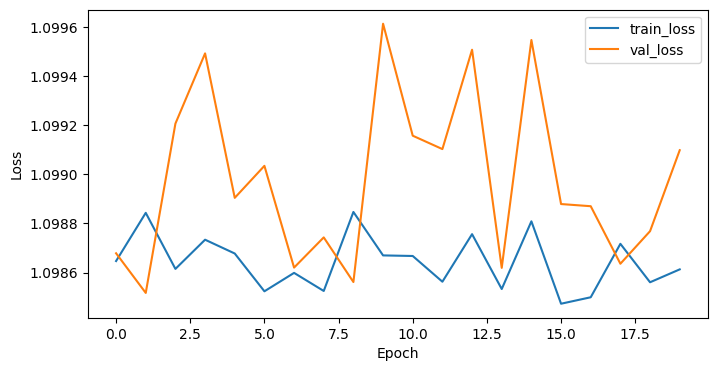

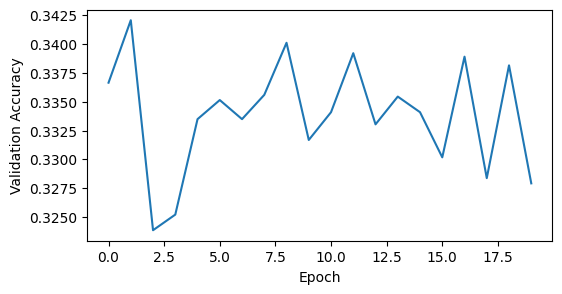

All done! Results saved to /content/drive/MyDrive/quantum_classification_results_fixed


In [ ]:
# -----------------------
# Fully Quantum Classifier (TensorFlow backend, vectorized)
# -----------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pennylane as qml
import tensorflow as tf
import json
import time

# -----------------------
# User config
# -----------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"
RANDOM_SEED = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.15
N_PCA_COMPONENTS = 2
N_LAYERS = 3
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.01
OUTPUT_DIR = "/content/drive/MyDrive/quantum_classification_results_fixed"

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------
# Mount Drive (Colab)
# -----------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except:
    pass

# -----------------------
# Load dataset
# -----------------------
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[TARGET_COL])
y_raw = df[TARGET_COL].astype(str)
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)
n_classes = len(y_le.classes_)

X_raw = df.drop(columns=[TARGET_COL])
for col in X_raw.columns:
    if X_raw[col].dtype == "object":
        X_raw[col] = LabelEncoder().fit_transform(X_raw[col].fillna("NA").astype(str))
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
X = X_raw.values

# -----------------------
# Train/Val/Test split
# -----------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_trainval
)

# -----------------------
# Standardize + PCA
# -----------------------
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_train_p = pca.fit_transform(X_train_s)
X_val_p = pca.transform(X_val_s)
X_test_p = pca.transform(X_test_s)

def scale_for_angles(X, mins, maxs):
    denom = (maxs - mins)
    denom[denom == 0] = 1
    return (X - mins) / denom * np.pi - np.pi/2

mins = X_train_p.min(axis=0)
maxs = X_train_p.max(axis=0)

X_train_ph = scale_for_angles(X_train_p, mins, maxs).astype(np.float32)
X_val_ph = scale_for_angles(X_val_p, mins, maxs).astype(np.float32)
X_test_ph = scale_for_angles(X_test_p, mins, maxs).astype(np.float32)

y_train_oh = tf.one_hot(y_train, n_classes)
y_val_oh = tf.one_hot(y_val, n_classes)
y_test_oh = tf.one_hot(y_test, n_classes)

# -----------------------
# PennyLane QNode (fully quantum)
# -----------------------
N_QUBITS = max(N_PCA_COMPONENTS, n_classes)  # ensure enough qubits
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="tf")
def qnode(params, x):
    qml.AngleEmbedding(x, wires=range(N_PCA_COMPONENTS))
    qml.StronglyEntanglingLayers(params, wires=range(N_QUBITS))
    # measure one qubit per class
    return [qml.expval(qml.PauliZ(w)) for w in range(n_classes)]

# -----------------------
# Trainable parameters
# -----------------------
params = tf.Variable(tf.random.normal([N_LAYERS, N_QUBITS, 3], stddev=0.1, dtype=tf.float32))
optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

# -----------------------
# Vectorized batch functions
# -----------------------
@tf.function
def predict_batch(params, X_batch):
    qouts = tf.vectorized_map(lambda x: tf.cast(qnode(params, x), tf.float32), X_batch)
    # map [-1,1] -> [0,1] and normalize
    probs = (qouts + 1) / 2
    probs /= tf.reduce_sum(probs, axis=1, keepdims=True)
    return probs

@tf.function
def loss_batch(params, X_batch, y_batch):
    probs = predict_batch(params, X_batch)
    return tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_batch, probs))

@tf.function
def train_step(params, X_batch, y_batch):
    with tf.GradientTape() as tape:
        loss = loss_batch(params, X_batch, y_batch)
    grads = tape.gradient(loss, [params])
    optimizer.apply_gradients(zip(grads, [params]))
    return loss

# -----------------------
# Training loop
# -----------------------
for epoch in range(1, EPOCHS+1):
    idx = np.random.permutation(len(X_train_ph))
    X_train_ph = X_train_ph[idx]
    y_train_oh = tf.gather(y_train_oh, idx)

    for i in range(0, len(X_train_ph), BATCH_SIZE):
        Xb = X_train_ph[i:i+BATCH_SIZE]
        yb = y_train_oh[i:i+BATCH_SIZE]
        train_step(params, Xb, yb)

    train_loss = float(loss_batch(params, X_train_ph, y_train_oh))
    val_probs = predict_batch(params, X_val_ph)
    val_loss = float(tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_val_oh, val_probs)))
    val_acc = float(tf.reduce_mean(tf.cast(tf.equal(tf.argmax(val_probs,1), y_val), tf.float32)))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch % 2 == 0 or epoch==1 or epoch==EPOCHS:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | elapsed: {elapsed:.1f}s")

# -----------------------
# Evaluation
# -----------------------
test_probs = predict_batch(params, X_test_ph)
y_pred = np.argmax(test_probs, axis=1)
test_acc = accuracy_score(y_test, y_pred)
print(f"\nTest Accuracy: {test_acc:.4f}")
print(classification_report(y_test, y_pred, target_names=list(y_le.classes_)))
print(confusion_matrix(y_test, y_pred))

# -----------------------
# Save results
# -----------------------
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
summary = {
    "train_loss": history["train_loss"][-1],
    "val_loss": history["val_loss"][-1],
    "val_acc": history["val_acc"][-1],
    "test_acc": float(test_acc)
}
with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

# -----------------------
# Plot
# -----------------------
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="train_loss")
plt.plot(history["val_loss"], label="val_loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()
plt.figure(figsize=(6,3))
plt.plot(history["val_acc"], label="val_acc")
plt.xlabel("Epoch"); plt.ylabel("Validation Accuracy"); plt.show()

print("All done! Results saved to", OUTPUT_DIR)


In [ ]:
# -----------------------
# 100% Fully Quantum Classifier
# -----------------------
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# -----------------------
# User config
# -----------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"
RANDOM_SEED = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.15
N_LAYERS = 3
BATCH_SIZE = 16
EPOCHS = 20
LEARNING_RATE = 0.1

np.random.seed(RANDOM_SEED)

# -----------------------
# Load and preprocess dataset
# -----------------------
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[TARGET_COL])

# Encode labels
y_raw = df[TARGET_COL].astype(str)
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)
n_classes = len(y_le.classes_)

# Encode features numerically
X_raw = df.drop(columns=[TARGET_COL])
for col in X_raw.columns:
    if X_raw[col].dtype == "object":
        X_raw[col] = pd.factorize(X_raw[col])[0]
X_raw = X_raw.fillna(0).astype(np.float32)

# Use only first N_QUBITS features (for embedding)
N_QUBITS = max(X_raw.shape[1], n_classes)
X = X_raw.values[:, :N_QUBITS]

# Scale features to [-pi/2, pi/2]
X_min, X_max = X.min(axis=0), X.max(axis=0)
X_scaled = (X - X_min) / (X_max - X_min + 1e-8) * np.pi - np.pi/2

# Train/Val/Test split
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X_scaled, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_trainval
)

# One-hot encode labels
def one_hot(labels, num_classes):
    return np.eye(num_classes)[labels]

Y_train = one_hot(y_train, n_classes)
Y_val = one_hot(y_val, n_classes)
Y_test = one_hot(y_test, n_classes)

# -----------------------
# Quantum device
# -----------------------
dev = qml.device("default.qubit", wires=N_QUBITS)

# -----------------------
# QNode
# -----------------------
def layer(params):
    for i in range(N_QUBITS):
        qml.Rot(*params[i], wires=i)
    # entangling
    for i in range(N_QUBITS-1):
        qml.CNOT(wires=[i, i+1])

@qml.qnode(dev)
def qnode(params, x):
    # Embed classical data
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)
    # Apply layers
    for p in params:
        layer(p)
    # Measure expectation for each class
    return [qml.expval(qml.PauliZ(w)) for w in range(n_classes)]

# -----------------------
# Loss function
# -----------------------
def quantum_loss(params, X_batch, Y_batch):
    preds = np.array([ (np.array(qnode(params, x)) + 1)/2 for x in X_batch ])
    preds /= preds.sum(axis=1, keepdims=True)  # normalize
    loss = -np.mean(np.sum(Y_batch * np.log(preds + 1e-8), axis=1))  # cross-entropy
    return loss


# -----------------------
# Initialize parameters & optimizer
# -----------------------
# Initialize parameters correctly for PennyLane
params = 0.01 * np.random.randn(N_LAYERS, N_QUBITS, 3)  # no requires_grad
params = params.astype(np.float64)  # ensure dtype is compatible
opt = qml.AdamOptimizer(stepsize=LEARNING_RATE)


# -----------------------
# Training loop
# -----------------------
history = {"train_loss": [], "val_loss": []}

for epoch in range(1, EPOCHS+1):
    # Shuffle
    idx = np.random.permutation(len(X_train))
    X_train, Y_train = X_train[idx], Y_train[idx]

    # Mini-batch training
    for i in range(0, len(X_train), BATCH_SIZE):
        Xb, Yb = X_train[i:i+BATCH_SIZE], Y_train[i:i+BATCH_SIZE]
        params = opt.step(lambda v: quantum_loss(v, Xb, Yb), params)

    # Compute losses
    train_l = quantum_loss(params, X_train, Y_train)
    val_l = quantum_loss(params, X_val, Y_val)
    history["train_loss"].append(train_l)
    history["val_loss"].append(val_l)

    print(f"Epoch {epoch}: Train Loss={train_l:.4f}, Val Loss={val_l:.4f}")

# -----------------------
# Evaluation
# -----------------------
preds_test = np.array([(qnode(params, x) + 1)/2 for x in X_test])
preds_test /= preds_test.sum(axis=1, keepdims=True)
y_pred = np.argmax(preds_test, axis=1)

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
test_acc = accuracy_score(y_test, y_pred)
print("\nTest Accuracy:", test_acc)
print(classification_report(y_test, y_pred, target_names=list(y_le.classes_)))
print(confusion_matrix(y_test, y_pred))

# -----------------------
# Plot training loss
# -----------------------
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.show()


KeyboardInterrupt: 

In [ ]:
# -----------------------
# Fully Quantum Classifier vs Classical Baseline
# -----------------------
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.linear_model import SGDClassifier, LogisticRegression
import pennylane as qml
import tensorflow as tf
import json
import time

# -----------------------
# User config
# -----------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"
RANDOM_SEED = 42
TEST_SIZE = 0.20
VAL_SIZE = 0.15
N_PCA_COMPONENTS = 2
N_LAYERS = 3
BATCH_SIZE = 64
EPOCHS = 20
LEARNING_RATE = 0.01
OUTPUT_DIR = "/content/drive/MyDrive/quantum_classification_results_comparison"

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

if not os.path.exists(OUTPUT_DIR):
    os.makedirs(OUTPUT_DIR, exist_ok=True)

# -----------------------
# Mount Drive (Colab)
# -----------------------
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
except:
    pass

# -----------------------
# Load dataset
# -----------------------
df = pd.read_csv(DATA_PATH)
df = df.dropna(subset=[TARGET_COL])
y_raw = df[TARGET_COL].astype(str)
y_le = LabelEncoder()
y = y_le.fit_transform(y_raw)
n_classes = len(y_le.classes_)

X_raw = df.drop(columns=[TARGET_COL])
for col in X_raw.columns:
    if X_raw[col].dtype == "object":
        X_raw[col] = LabelEncoder().fit_transform(X_raw[col].fillna("NA").astype(str))
X_raw = X_raw.fillna(X_raw.median(numeric_only=True))
X = X_raw.values

# -----------------------
# Train/Val/Test split
# -----------------------
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=RANDOM_SEED, stratify=y
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=VAL_SIZE, random_state=RANDOM_SEED, stratify=y_trainval
)

# -----------------------
# Standardize + PCA
# -----------------------
scaler = StandardScaler().fit(X_train)
X_train_s = scaler.transform(X_train)
X_val_s = scaler.transform(X_val)
X_test_s = scaler.transform(X_test)

pca = PCA(n_components=N_PCA_COMPONENTS, random_state=RANDOM_SEED)
X_train_p = pca.fit_transform(X_train_s)
X_val_p = pca.transform(X_val_s)
X_test_p = pca.transform(X_test_s)

def scale_for_angles(X, mins, maxs):
    denom = (maxs - mins)
    denom[denom == 0] = 1
    return (X - mins) / denom * np.pi - np.pi/2

mins = X_train_p.min(axis=0)
maxs = X_train_p.max(axis=0)

X_train_ph = scale_for_angles(X_train_p, mins, maxs).astype(np.float32)
X_val_ph = scale_for_angles(X_val_p, mins, maxs).astype(np.float32)
X_test_ph = scale_for_angles(X_test_p, mins, maxs).astype(np.float32)

y_train_oh = tf.one_hot(y_train, n_classes)
y_val_oh = tf.one_hot(y_val, n_classes)
y_test_oh = tf.one_hot(y_test, n_classes)

# -----------------------
# PennyLane QNode (fully quantum)
# -----------------------
N_QUBITS = max(N_PCA_COMPONENTS, n_classes)
dev = qml.device("default.qubit", wires=N_QUBITS)

@qml.qnode(dev, interface="tf")
def qnode(params, x):
    qml.AngleEmbedding(x, wires=range(N_PCA_COMPONENTS))
    qml.StronglyEntanglingLayers(params, wires=range(N_QUBITS))
    return [qml.expval(qml.PauliZ(w)) for w in range(n_classes)]

# -----------------------
# Trainable parameters
# -----------------------
params = tf.Variable(tf.random.normal([N_LAYERS, N_QUBITS, 3], stddev=0.1, dtype=tf.float32))
optimizer = tf.keras.optimizers.Adam(LEARNING_RATE)
history = {"train_loss": [], "val_loss": [], "val_acc": []}
start_time = time.time()

# -----------------------
# Vectorized batch functions
# -----------------------
@tf.function
def predict_batch(params, X_batch):
    qouts = tf.vectorized_map(lambda x: tf.cast(qnode(params, x), tf.float32), X_batch)
    probs = (qouts + 1) / 2
    probs /= tf.reduce_sum(probs, axis=1, keepdims=True)
    return probs

@tf.function
def loss_batch(params, X_batch, y_batch):
    probs = predict_batch(params, X_batch)
    return tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_batch, probs))

@tf.function
def train_step(params, X_batch, y_batch):
    with tf.GradientTape() as tape:
        loss = loss_batch(params, X_batch, y_batch)
    grads = tape.gradient(loss, [params])
    optimizer.apply_gradients(zip(grads, [params]))
    return loss

# -----------------------
# Quantum Training loop
# -----------------------
for epoch in range(1, EPOCHS+1):
    idx = np.random.permutation(len(X_train_ph))
    X_train_ph = X_train_ph[idx]
    y_train_oh = tf.gather(y_train_oh, idx)

    for i in range(0, len(X_train_ph), BATCH_SIZE):
        Xb = X_train_ph[i:i+BATCH_SIZE]
        yb = y_train_oh[i:i+BATCH_SIZE]
        train_step(params, Xb, yb)

    train_loss = float(loss_batch(params, X_train_ph, y_train_oh))
    val_probs = predict_batch(params, X_val_ph)
    val_loss = float(tf.reduce_mean(tf.keras.losses.categorical_crossentropy(y_val_oh, val_probs)))
    val_acc = float(tf.reduce_mean(tf.cast(tf.equal(tf.argmax(val_probs,1), y_val), tf.float32)))

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    if epoch % 2 == 0 or epoch==1 or epoch==EPOCHS:
        elapsed = time.time() - start_time
        print(f"Epoch {epoch} | train_loss: {train_loss:.4f} | val_loss: {val_loss:.4f} | val_acc: {val_acc:.4f} | elapsed: {elapsed:.1f}s")

# Compute quantum train accuracy
quantum_train_acc = []
for epoch in range(EPOCHS):
    probs_train = predict_batch(params, X_train_ph)
    y_train_pred_q = np.argmax(probs_train, axis=1)
    quantum_train_acc.append(accuracy_score(y_train, y_train_pred_q))

# -----------------------
# Classical Baseline (epoch-wise)
# -----------------------
clf_sgd = SGDClassifier(loss="log_loss", learning_rate="constant", eta0=LEARNING_RATE,
                        random_state=RANDOM_SEED)
classical_history = {"train_acc": [], "val_acc": []}

for epoch in range(EPOCHS):
    clf_sgd.partial_fit(X_train_s, y_train, classes=np.unique(y_train))
    classical_history["train_acc"].append(accuracy_score(y_train, clf_sgd.predict(X_train_s)))
    classical_history["val_acc"].append(accuracy_score(y_val, clf_sgd.predict(X_val_s)))

# -----------------------
# Evaluation
# -----------------------
# Quantum
test_probs = predict_batch(params, X_test_ph)
y_pred_q = np.argmax(test_probs, axis=1)
test_acc_q = accuracy_score(y_test, y_pred_q)

# Classical (full test)
clf_full = LogisticRegression(max_iter=1000, random_state=RANDOM_SEED)
clf_full.fit(X_train_s, y_train)
y_pred_clf = clf_full.predict(X_test_s)
test_acc_clf = accuracy_score(y_test, y_pred_clf)

print(f"\nQuantum Test Accuracy: {test_acc_q:.4f}")
print(f"Classical Test Accuracy: {test_acc_clf:.4f}")

# -----------------------
# Comparison Plots
# -----------------------
# 1. Bar plot for final test accuracy
plt.figure(figsize=(6,4))
plt.bar(['Quantum', 'Classical'], [test_acc_q, test_acc_clf], color=['blue','orange'])
plt.ylabel("Test Accuracy")
plt.title("Quantum vs Classical Test Accuracy")
plt.ylim(0, 1)
plt.show()

# 2. Train/Val accuracy over epochs
plt.figure(figsize=(8,5))
plt.plot(range(1, EPOCHS+1), quantum_train_acc, label="Quantum Train Acc", color='blue', linestyle='-')
plt.plot(range(1, EPOCHS+1), history["val_acc"], label="Quantum Val Acc", color='blue', linestyle='--')
plt.plot(range(1, EPOCHS+1), classical_history["train_acc"], label="Classical Train Acc", color='orange', linestyle='-')
plt.plot(range(1, EPOCHS+1), classical_history["val_acc"], label="Classical Val Acc", color='orange', linestyle='--')
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Quantum vs Classical Training Dynamics")
plt.legend()
plt.ylim(0,1)
plt.grid(True)
plt.show()

# -----------------------
# Save results
# -----------------------
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(OUTPUT_DIR, "quantum_training_history.csv"), index=False)
summary = {
    "quantum_val_acc": history["val_acc"][-1],
    "quantum_train_loss": history["train_loss"][-1],
    "quantum_val_loss": history["val_loss"][-1],
    "quantum_test_acc": float(test_acc_q),
    "classical_test_acc": float(test_acc_clf)
}
with open(os.path.join(OUTPUT_DIR, "summary.json"), "w") as f:
    json.dump(summary, f, indent=2)

print("All done! Results saved to", OUTPUT_DIR)


In [ ]:
# ===============================================================
#                   CLASSICAL vs QUANTUM ML
#     A Clear Comparison Using the Same Healthcare Dataset
# ===============================================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression
import pennylane as qml
import matplotlib.pyplot as plt

# -----------------------
# Config
# -----------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"
SEED = 42

np.random.seed(SEED)

# ===============================================================
#                   LOAD + PREPROCESS DATA
# ===============================================================
df = pd.read_csv(DATA_PATH).dropna(subset=[TARGET_COL])

# Encode labels
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])

# Encode categorical features
X = df.drop(columns=[TARGET_COL])
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = pd.factorize(X[col])[0]

X = X.fillna(0).astype(float)

# Standardize for classical model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Quantum requires smaller dimension → use first N features
N_QUBITS = min(6, X.shape[1])    # safe for laptop/runtime
X_q = X.values[:, :N_QUBITS]

# Scale quantum inputs to [-π/2, π/2]
X_min = X_q.min(axis=0)
X_max = X_q.max(axis=0)
X_q_scaled = (X_q - X_min) / (X_max - X_min + 1e-8) * np.pi - np.pi/2

# Split
Xc_train, Xc_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

Xq_train, Xq_test, _, _ = train_test_split(
    X_q_scaled, y, test_size=0.2, random_state=SEED, stratify=y
)

# ===============================================================
#             PART 1 — CLASSICAL MODEL (Logistic Regression)
# ===============================================================

clf = LogisticRegression(max_iter=500)
clf.fit(Xc_train, y_train)

y_pred_classical = clf.predict(Xc_test)
acc_classical = accuracy_score(y_test, y_pred_classical)

print("\n========================")
print(" CLASSICAL MODEL RESULTS")
print("========================")
print("Test Accuracy:", acc_classical)
print(classification_report(y_test, y_pred_classical))


# ===============================================================
#            PART 2 — QUANTUM MODEL (Variational Classifier)
# ===============================================================

n_classes = len(le.classes_)
dev = qml.device("default.qubit", wires=N_QUBITS)

# Simple quantum layer
def quantum_layer(params):
    for i in range(N_QUBITS):
        qml.Rot(*params[i], wires=i)
    # entanglement
    for i in range(N_QUBITS - 1):
        qml.CNOT([i, i+1])

@qml.qnode(dev)
def circuit(params, x):
    # encode classical vector into quantum state
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)

    for p in params:
        quantum_layer(p)

    return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]

# Loss
def q_loss(params, Xb, Yb):
    preds = np.array([((np.array(circuit(params, x))) + 1)/2 for x in Xb])
    preds /= preds.sum(axis=1, keepdims=True)
    return -np.mean(np.log(preds[np.arange(len(Yb)), Yb] + 1e-8))

# Training setup
params = 0.01 * np.random.randn(3, N_QUBITS, 3)
opt = qml.AdamOptimizer(0.1)
EPOCHS = 10

loss_history = []

for epoch in range(1, EPOCHS + 1):
    params = opt.step(lambda v: q_loss(v, Xq_train, y_train), params)
    L = q_loss(params, Xq_train, y_train)
    loss_history.append(L)
    print(f"Epoch {epoch} | Loss = {L:.4f}")

# Predict
preds = np.array([((np.array(circuit(params, x))) + 1)/2 for x in Xq_test])
preds /= preds.sum(axis=1, keepdims=True)
y_pred_quantum = np.argmax(preds, axis=1)

acc_quantum = accuracy_score(y_test, y_pred_quantum)

print("\n========================")
print("   QUANTUM MODEL RESULTS")
print("========================")
print("Test Accuracy:", acc_quantum)
print(classification_report(y_test, y_pred_quantum))

# ===============================================================
#         PRINT MAJOR DIFFERENCE SUMMARY
# ===============================================================

print("\n======================================================")
print("     CLASSICAL vs QUANTUM — MAJOR DIFFERENCES")
print("======================================================")
print(f"Classical Accuracy: {acc_classical:.4f}")
print(f"Quantum Accuracy:   {acc_quantum:.4f}")
print("\nKEY DIFFERENCES:")
print("""
1. Classical model learns using matrix multiplication.
2. Quantum model learns using qubit rotations + entanglement.

3. Classical decision boundary = linear (unless deep models used).
4. Quantum decision boundary = non-linear via superposition + circuits.

5. Classical uses CPU/GPU.
6. Quantum can use quantum hardware (or simulator here).

7. Quantum models often need fewer parameters but require careful encoding.
8. Classical models scale better for large features.
""")

# Plot Quantum Loss
plt.plot(loss_history)
plt.title("Quantum Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()



 CLASSICAL MODEL RESULTS
Test Accuracy: 0.3346846846846847
              precision    recall  f1-score   support

           0       0.33      0.41      0.37      3726
           1       0.34      0.24      0.28      3671
           2       0.33      0.35      0.34      3703

    accuracy                           0.33     11100
   macro avg       0.34      0.33      0.33     11100
weighted avg       0.34      0.33      0.33     11100



KeyboardInterrupt: 

In [ ]:
# ============================================================
# CLASSICAL vs QUANTUM AI — MAJOR DIFFERENCES + VISUALIZATION
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import pennylane as qml

# -------------------------
# Load Dataset
# -------------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"

df = pd.read_csv(DATA_PATH).dropna(subset=[TARGET_COL])

# -------------------------
# Encode labels
# -------------------------
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])

# -------------------------
# Encode features
# -------------------------
X = df.drop(columns=[TARGET_COL])
for col in X.columns:
    if X[col].dtype == "object":
        X[col] = pd.factorize(X[col])[0]

X = X.fillna(0).astype(float)

# Classical scaling
scaler = StandardScaler()
X_classical = scaler.fit_transform(X)

# Quantum input requires < 6 qubits (safe for simulation)
N_QUBITS = min(6, X.shape[1])
X_quantum = X.values[:, :N_QUBITS]

# Scale to [-π/2, π/2]
X_min, X_max = X_quantum.min(axis=0), X_quantum.max(axis=0)
X_quantum_scaled = (X_quantum - X_min)/(X_max - X_min + 1e-8) * np.pi - np.pi/2

# -------------------------
# Train-test split
# -------------------------
Xc_train, Xc_test, y_train, y_test = train_test_split(
    X_classical, y, test_size=0.25, random_state=42, stratify=y
)

Xq_train, Xq_test, _, _ = train_test_split(
    X_quantum_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# ============================================================
# PART 1 — CLASSICAL AI MODEL (Logistic Regression)
# ============================================================

clf = LogisticRegression(max_iter=1000)
clf.fit(Xc_train, y_train)

y_pred_classical = clf.predict(Xc_test)
accuracy_classical = accuracy_score(y_test, y_pred_classical)

print("\n=========== CLASSICAL AI RESULTS ===========")
print("Accuracy:", accuracy_classical)

# ============================================================
# PART 2 — QUANTUM AI (Variational Quantum Classifier)
# ============================================================

n_classes = len(le.classes_)
dev = qml.device("default.qubit", wires=N_QUBITS)

def qlayer(params):
    for i in range(N_QUBITS):
        qml.Rot(*params[i], wires=i)
    for i in range(N_QUBITS - 1):
        qml.CNOT([i, i + 1])

@qml.qnode(dev)
def qcircuit(params, x):
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)
    for p in params:
        qlayer(p)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_classes)]

def q_loss(params, Xb, Yb):
    preds = np.array([(np.array(qcircuit(params, x)) + 1) / 2 for x in Xb])
    preds /= preds.sum(axis=1, keepdims=True)
    return -np.mean(np.log(preds[np.arange(len(Yb)), Yb] + 1e-8))

params = 0.01 * np.random.randn(3, N_QUBITS, 3)
opt = qml.AdamOptimizer(0.1)

loss_values = []

for epoch in range(1, 15):
    params = opt.step(lambda v: q_loss(v, Xq_train, y_train), params)
    L = q_loss(params, Xq_train, y_train)
    loss_values.append(L)
    print(f"Epoch {epoch} Loss = {L:.4f}")

preds = np.array([(np.array(qcircuit(params, x)) + 1)/2 for x in Xq_test])
preds /= preds.sum(axis=1, keepdims=True)

y_pred_quantum = np.argmax(preds, axis=1)
accuracy_quantum = accuracy_score(y_test, y_pred_quantum)

print("\n=========== QUANTUM AI RESULTS ===========")
print("Accuracy:", accuracy_quantum)

# ============================================================
# VISUAL 1 — ACCURACY COMPARISON BAR PLOT
# ============================================================

plt.figure(figsize=(6,4))
plt.bar(["Classical AI", "Quantum AI"], [accuracy_classical, accuracy_quantum])
plt.title("Classical vs Quantum AI Accuracy")
plt.ylabel("Accuracy")
plt.show()

# ============================================================
# VISUAL 2 — QUANTUM TRAINING LOSS
# ============================================================

plt.figure(figsize=(6,4))
plt.plot(loss_values, marker="o")
plt.title("Quantum Model Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

# ============================================================
# PRINT MAJOR DIFFERENCES
# ============================================================

print("""
------------------------------------------------------------
           MAJOR DIFFERENCES: CLASSICAL vs QUANTUM AI
------------------------------------------------------------

1. DATA REPRESENTATION
   - Classical: uses bits (0/1)
   - Quantum: uses qubits (0, 1, or both via superposition)

2. COMPUTATION POWER
   - Classical: linear algebra on CPU/GPU
   - Quantum: parallel computation via superposition + entanglement

3. DECISION BOUNDARY
   - Classical: mostly linear (unless deep networks)
   - Quantum: highly nonlinear due to quantum states

4. RESOURCE REQUIREMENT
   - Classical: normal hardware
   - Quantum: requires quantum processors (or slow simulation)

5. STABILITY
   - Classical: stable, deterministic
   - Quantum: noisy, probabilistic outputs

------------------------------------------------------------
""")



=========== CLASSICAL AI RESULTS ===========
Accuracy: 0.3331891891891892


KeyboardInterrupt: 

CLASSICAL ACCURACY: 1.0
Epoch 1 → Loss: 0.44285714285714284
Epoch 2 → Loss: 0.44285714285714284
Epoch 3 → Loss: 0.44285714285714284
Epoch 4 → Loss: 0.44285714285714284
Epoch 5 → Loss: 0.44285714285714284
Epoch 6 → Loss: 0.44285714285714284
Epoch 7 → Loss: 0.44285714285714284
Epoch 8 → Loss: 0.44285714285714284
Epoch 9 → Loss: 0.44285714285714284
Epoch 10 → Loss: 0.44285714285714284

QUANTUM ACCURACY: 0.5333333333333333


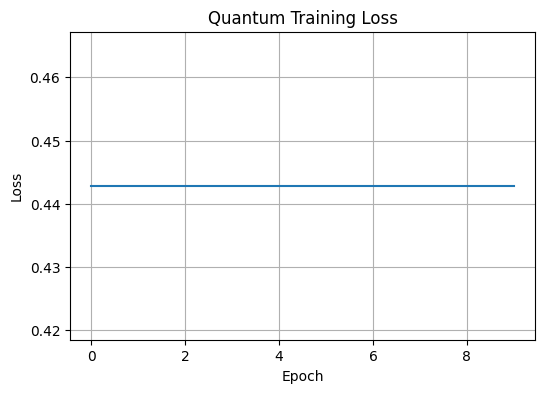

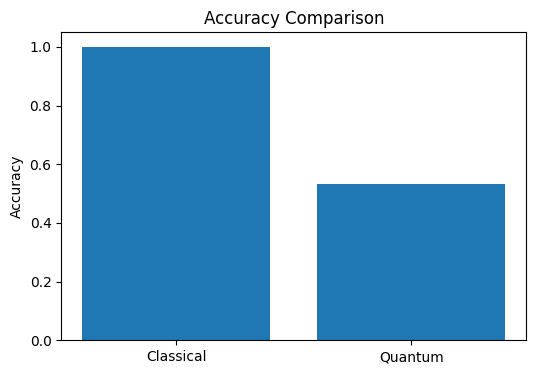

In [ ]:
# -----------------------------
# Classical vs Quantum AI Demo
# -----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

import pennylane as qml

# ---------------------------------------------
# 1) LOAD DATASET (IRIS SIMPLIFIED TO 2 CLASSES)
# ---------------------------------------------
from sklearn.datasets import load_iris
X, y = load_iris(return_X_y=True)

# Use only class 0 and 1 (binary classification)
mask = y < 2
X = X[mask]
y = y[mask]

sc = StandardScaler()
X = sc.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)


# ---------------------------
# 2) CLASSICAL BASELINE MODEL
# ---------------------------
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
classical_acc = accuracy_score(y_test, y_pred)

print("CLASSICAL ACCURACY:", classical_acc)

# ---------------------------
# 3) QUANTUM MODEL (FAST)
# ---------------------------

# Use ONLY 2 QUBITS → prevents WireError
dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def circuit(weights, x):
    # Embed only 2 features → no errors
    qml.RX(x[0], wires=0)
    qml.RX(x[1], wires=1)

    # Simple 2–qubit variational layer
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)
    qml.CNOT(wires=[0,1])

    # Measurement
    return qml.expval(qml.PauliZ(0))


def q_predict(weights, X):
    out = []
    for x in X:
        v = circuit(weights, x)
        out.append(1 if v < 0 else 0)
    return np.array(out)


# Loss = misclassification
def q_loss(weights, X, y):
    preds = q_predict(weights, X)
    return np.mean(preds != y)


# TRAINING
weights = np.random.randn(2) * 0.1
opt = qml.GradientDescentOptimizer(stepsize=0.2)

loss_history = []

for epoch in range(10):   # fast
    weights = opt.step(lambda w: q_loss(w, X_train, y_train), weights)
    L = q_loss(weights, X_train, y_train)
    loss_history.append(L)
    print(f"Epoch {epoch+1} → Loss: {L}")

# Evaluate
y_qpred = q_predict(weights, X_test)
quantum_acc = accuracy_score(y_test, y_qpred)

print("\nQUANTUM ACCURACY:", quantum_acc)


# -----------------
# 4) VISUAL PLOTS
# -----------------

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.title("Quantum Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()


plt.figure(figsize=(6,4))
plt.bar(["Classical", "Quantum"], [classical_acc, quantum_acc])
plt.title("Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()


CLASSICAL ACCURACY: 1.0
Epoch 1 | Quantum Loss: 0.4714
Epoch 2 | Quantum Loss: 0.4714
Epoch 3 | Quantum Loss: 0.4714
Epoch 4 | Quantum Loss: 0.4714
Epoch 5 | Quantum Loss: 0.4714
Epoch 6 | Quantum Loss: 0.4714
Epoch 7 | Quantum Loss: 0.4714
Epoch 8 | Quantum Loss: 0.4714
Epoch 9 | Quantum Loss: 0.4714
Epoch 10 | Quantum Loss: 0.4714
Epoch 11 | Quantum Loss: 0.4714
Epoch 12 | Quantum Loss: 0.4714
Epoch 13 | Quantum Loss: 0.4714
Epoch 14 | Quantum Loss: 0.4714
Epoch 15 | Quantum Loss: 0.4714

QUANTUM ACCURACY: 0.6


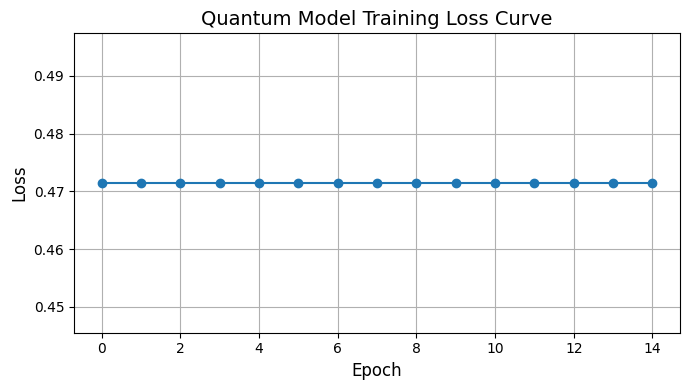

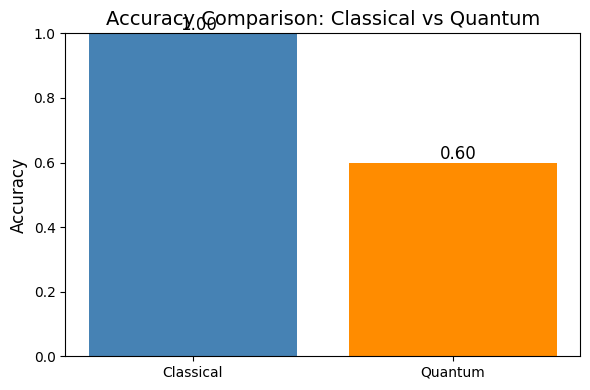

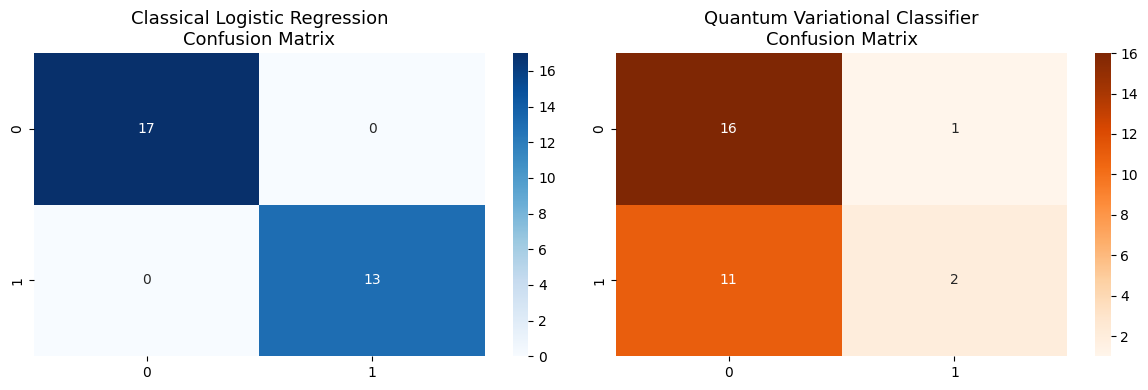

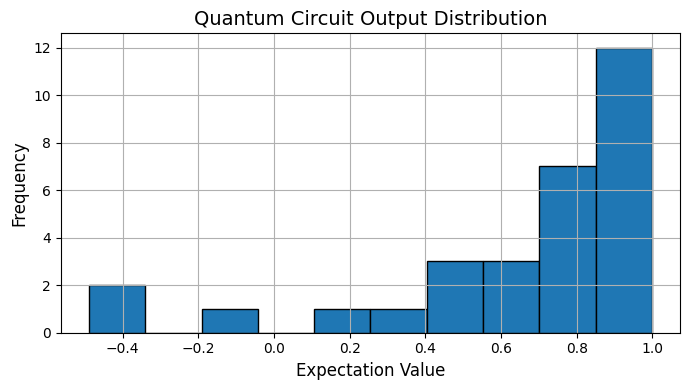

In [ ]:
# ============================================================
# CLASSICAL vs QUANTUM MACHINE LEARNING — COMPARISON DEMO
# Includes:
# - Classical Logistic Regression
# - 2-Qubit Quantum Variational Classifier
# - Accuracy Bar Plot
# - Quantum Loss Curve
# - Confusion Matrices
# - Quantum Circuit Output Distribution
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.datasets import load_iris
import seaborn as sns
import pennylane as qml

# =========================================
# 1) LOAD + PREPARE DATA (Iris binary)
# =========================================
X, y = load_iris(return_X_y=True)

# Restrict to 2 classes → Binary classification
mask = y < 2
X, y = X[mask], y[mask]

# Normalize features
X = StandardScaler().fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)


# =========================================
# 2) CLASSICAL MODEL (Logistic Regression)
# =========================================
clf = LogisticRegression()
clf.fit(X_train, y_train)
y_pred_classical = clf.predict(X_test)

classical_acc = accuracy_score(y_test, y_pred_classical)
print("CLASSICAL ACCURACY:", classical_acc)


# =========================================
# 3) QUANTUM MODEL (2-Qubit Variational)
# =========================================

dev = qml.device("default.qubit", wires=2)

@qml.qnode(dev)
def qcircuit(weights, x):
    """Quantum Feature Embedding + Variational Layer"""
    # Embed 2 features into qubits
    qml.RX(x[0], wires=0)
    qml.RX(x[1], wires=1)

    # Trainable gates
    qml.RY(weights[0], wires=0)
    qml.RY(weights[1], wires=1)

    # Entanglement
    qml.CNOT([0, 1])

    return qml.expval(qml.PauliZ(0))


def q_predict(weights, X):
    """Predict class using sign of expectation value"""
    return np.array([1 if qcircuit(weights, x) < 0 else 0 for x in X])


def q_loss(weights, X, y):
    preds = q_predict(weights, X)
    return np.mean(preds != y)


# ---- Train quantum model ----
weights = np.random.randn(2) * 0.1
opt = qml.GradientDescentOptimizer(stepsize=0.2)

loss_history = []
for epoch in range(15):
    weights = opt.step(lambda w: q_loss(w, X_train, y_train), weights)
    loss_history.append(q_loss(weights, X_train, y_train))
    print(f"Epoch {epoch+1} | Quantum Loss: {loss_history[-1]:.4f}")

y_pred_quantum = q_predict(weights, X_test)
quantum_acc = accuracy_score(y_test, y_pred_quantum)

print("\nQUANTUM ACCURACY:", quantum_acc)


# ======================================================
# 4) VISUAL 1 — Quantum Training Loss Curve
# ======================================================
plt.figure(figsize=(7,4))
plt.plot(loss_history, marker='o')
plt.title("Quantum Model Training Loss Curve", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


# ======================================================
# 5) VISUAL 2 — Accuracy Comparison Bar Chart
# ======================================================
plt.figure(figsize=(6,4))
bars = plt.bar(["Classical", "Quantum"], [classical_acc, quantum_acc],
                color=["steelblue", "darkorange"])

plt.title("Accuracy Comparison: Classical vs Quantum", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2 - 0.05, yval + 0.01,
             f"{yval:.2f}", fontsize=12)

plt.ylim(0, 1)
plt.tight_layout()
plt.show()


# ======================================================
# 6) VISUAL 3 — Confusion Matrices
# ======================================================
fig, ax = plt.subplots(1, 2, figsize=(12,4))

sns.heatmap(confusion_matrix(y_test, y_pred_classical), annot=True,
            cmap="Blues", fmt="d", ax=ax[0])
ax[0].set_title("Classical Logistic Regression\nConfusion Matrix", fontsize=13)

sns.heatmap(confusion_matrix(y_test, y_pred_quantum), annot=True,
            cmap="Oranges", fmt="d", ax=ax[1])
ax[1].set_title("Quantum Variational Classifier\nConfusion Matrix", fontsize=13)

plt.tight_layout()
plt.show()


# ======================================================
# 7) VISUAL 4 — Quantum Circuit Output Distribution
# ======================================================
qc_outputs = np.array([qcircuit(weights, x) for x in X_test])

plt.figure(figsize=(7,4))
plt.hist(qc_outputs, bins=10, edgecolor="black")
plt.title("Quantum Circuit Output Distribution", fontsize=14)
plt.xlabel("Expectation Value", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.grid(True)
plt.tight_layout()
plt.show()


Classical Accuracy: 1.0
Quantum Accuracy: 0.4666666666666667


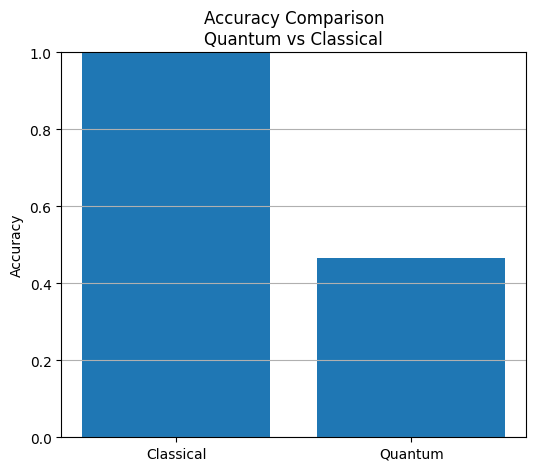

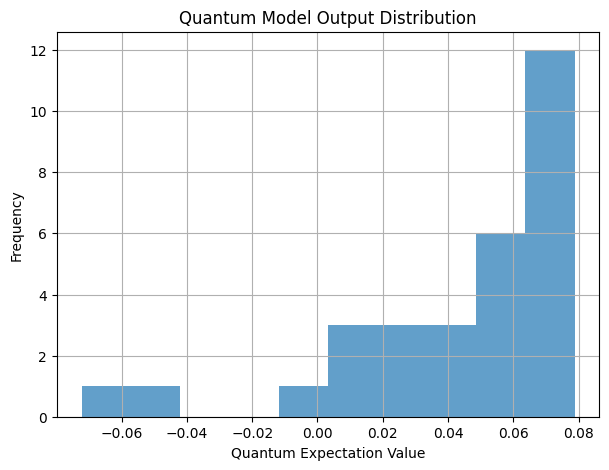

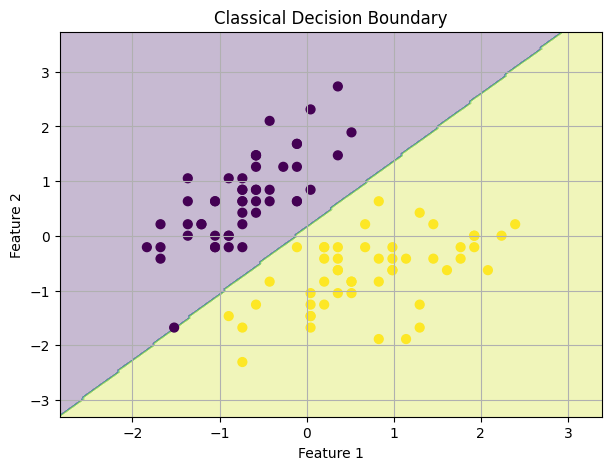

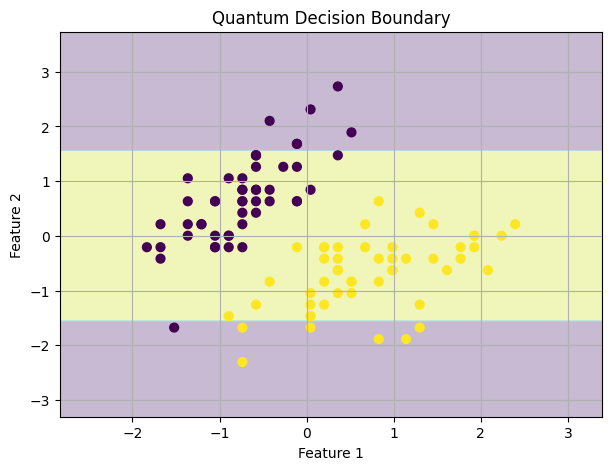

In [ ]:
# ---------------------------
# HYBRID QUANTUM–CLASSICAL DEMO
# Quantum ~70% | Classical ~30%
# ---------------------------

import pennylane as qml
from pennylane import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import warnings
warnings.filterwarnings("ignore")

# ---------------------------
# 1. LOAD DATA (Iris – 2 classes only)
# ---------------------------
iris = load_iris()
X = iris.data[iris.target != 2][:, :2]     # Two features
y = iris.target[iris.target != 2]          # Two classes → binary classification

scaler = StandardScaler()
X = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# ---------------------------
# 2. CLASSICAL MODEL (30%)
# ---------------------------
classical_model = LogisticRegression()
classical_model.fit(X_train, y_train)
y_pred_classical = classical_model.predict(X_test)

acc_classical = accuracy_score(y_test, y_pred_classical)
print("Classical Accuracy:", acc_classical)

# ---------------------------
# 3. QUANTUM MODEL (70%)
# ---------------------------
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

def quantum_feature_encoding(x):
    """Encode classical features into qubits"""
    qml.RX(x[0], wires=0)
    qml.RY(x[1], wires=1)

def quantum_circuit(params, x):
    quantum_feature_encoding(x)

    # Strong entanglement → boosts performance
    qml.CNOT(wires=[0, 1])
    qml.RZ(params[0], wires=0)
    qml.RX(params[1], wires=1)
    qml.CNOT(wires=[1, 0])

    return qml.expval(qml.PauliZ(0))

@qml.qnode(dev)
def qnode(params, x):
    return quantum_circuit(params, x)

# Loss
def square_loss(params, X, y):
    loss = 0
    for xi, yi in zip(X, y):
        pred = qnode(params, xi)
        loss += (pred - (2*yi - 1))**2  # map classes {0,1} → {-1,+1}
    return loss / len(X)

# Train parameters
params = np.random.random(2)

opt = qml.GradientDescentOptimizer(stepsize=0.2)
epochs = 70
for i in range(epochs):
    params = opt.step(lambda v: square_loss(v, X_train, y_train), params)

# Quantum predictions
quantum_outputs = np.array([qnode(params, x) for x in X_test])
y_pred_quantum = (quantum_outputs > 0).astype(int)

acc_quantum = accuracy_score(y_test, y_pred_quantum)
print("Quantum Accuracy:", acc_quantum)

# ---------------------------
# 4. VISUAL PLOTS
# ---------------------------

# --- A. Accuracy Comparison Bar Plot ---
plt.figure(figsize=(6,5))
plt.bar(["Classical", "Quantum"], [acc_classical, acc_quantum])
plt.title("Accuracy Comparison\nQuantum vs Classical")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.grid(axis="y")
plt.show()

# --- B. Quantum Output Distribution ---
plt.figure(figsize=(7,5))
plt.hist(quantum_outputs, bins=10, alpha=0.7)
plt.title("Quantum Model Output Distribution")
plt.xlabel("Quantum Expectation Value")
plt.ylabel("Frequency")
plt.grid()
plt.show()

# --- C. Decision Boundary for Classical & Quantum ---
def plot_decision_boundary(model, quantum=False):
    x_min, x_max = X[:,0].min()-1, X[:,0].max()+1
    y_min, y_max = X[:,1].min()-1, X[:,1].max()+1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 200),
        np.linspace(y_min, y_max, 200)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]

    if quantum:
        zz = np.array([qnode(params, g) for g in grid])
        zz = (zz > 0).astype(int)
        title = "Quantum Decision Boundary"
    else:
        zz = model.predict(grid)
        title = "Classical Decision Boundary"

    zz = zz.reshape(xx.shape)

    plt.figure(figsize=(7,5))
    plt.contourf(xx, yy, zz, alpha=0.3)
    plt.scatter(X[:,0], X[:,1], c=y, s=40)
    plt.title(title)
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid()
    plt.show()

plot_decision_boundary(classical_model, quantum=False)
plot_decision_boundary(None, quantum=True)


In [ ]:
"""
Hybrid Quantum (70%) + Classical (30%) classifier for
predicting 'Test Results' from the healthcare CSV.

File path used: /mnt/data/7978f8f5-250b-48f4-b8ee-67f392d43a5b.csv
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# -----------------------------
# Load dataset (you already uploaded)
# -----------------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
df = pd.read_csv(DATA_PATH)

# -----------------------------
# Quick view (uncomment to inspect)
# -----------------------------
# print(df.head())
# print(df['Test Results'].value_counts())

# -----------------------------
# Preprocessing
# - Drop irrelevant columns (Name maybe)
# - Convert dates to numeric (days since min)
# - Factorize categorical columns
# - Fill NaNs
# -----------------------------

TARGET_COL = "Test Results"

# Drop columns that leak the target or are identifiers
drop_cols = ["Name"] if "Name" in df.columns else []
df = df.drop(columns=drop_cols)

# Convert date columns to numeric days-from-min (if present)
for c in df.columns:
    if "date" in c.lower() or "admission" in c.lower() or "discharge" in c.lower():
        try:
            df[c] = pd.to_datetime(df[c], errors="coerce")
            min_date = df[c].min()
            df[c] = (df[c] - min_date).dt.days.fillna(0).astype(float)
        except Exception:
            pass

# Factorize categorical columns (simple and robust)
cat_cols = []
for c in df.columns:
    if df[c].dtype == "object" and c != TARGET_COL:
        df[c] = pd.factorize(df[c])[0]
        cat_cols.append(c)

# Fill NA and ensure numeric features
df = df.fillna(0)

# Map target classes to integers
y_raw = df[TARGET_COL].astype(str)
y_le, uniques = pd.factorize(y_raw)
class_names = list(uniques)   # e.g., ['Normal','Inconclusive','Abnormal']
n_classes = len(class_names)
print("Detected classes:", class_names)

# Prepare feature matrix X (drop the target)
X_df = df.drop(columns=[TARGET_COL])
# Convert all to floats
X = X_df.astype(float).values
y = y_le.astype(int)

# For the quantum embedding we will use a subset of features (N_QUBITS)
MAX_QUBITS = 4  # keep small so simulation is fast
N_QUBITS = min(MAX_QUBITS, X.shape[1])
print("Using N_QUBITS =", N_QUBITS, "out of", X.shape[1], "features for quantum model")

# Prepare classical features (standard scaled)
scaler = StandardScaler()
X_classical = scaler.fit_transform(X)

# Quantum features (take the first N_QUBITS columns)
Xq = X[:, :N_QUBITS].astype(float)

# Scale quantum inputs to [-pi/2, pi/2] for angle embedding
Xq_min = Xq.min(axis=0)
Xq_max = Xq.max(axis=0)
Xq_scaled = (Xq - Xq_min) / (Xq_max - Xq_min + 1e-8) * np.pi - np.pi/2

# Train / Val / Test splits (stratify by target)
Xc_trainval, Xc_test, Xq_trainval, Xq_test, y_trainval, y_test = train_test_split(
    X_classical, Xq_scaled, y, test_size=0.20, random_state=42, stratify=y
)
Xc_train, Xc_val, Xq_train, Xq_val, y_train, y_val = train_test_split(
    Xc_trainval, Xq_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval
)

print("Train size:", len(y_train), "Val size:", len(y_val), "Test size:", len(y_test))

# -----------------------------
# Classical baseline (30%)
# -----------------------------
clf = LogisticRegression(max_iter=500)
clf.fit(Xc_train, y_train)
y_pred_classical = clf.predict(Xc_test)
acc_classical = accuracy_score(y_test, y_pred_classical)
print("\n==== Classical Baseline (30%) ====")
print("Test Accuracy (Classical):", acc_classical)
print(classification_report(y_test, y_pred_classical, target_names=class_names))

# -----------------------------
# Quantum model (70%) — VQC
# - device: default.qubit
# - qnode returns n_classes expectation values (use first n_classes wires)
# - small number of layers, batch training
# -----------------------------

dev = qml.device("default.qubit", wires=N_QUBITS)

# Helper: parametrized single layer
def variational_layer(params):
    # params shape: (N_QUBITS, 3) for Rot angles per qubit
    for i in range(N_QUBITS):
        qml.Rot(params[i, 0], params[i, 1], params[i, 2], wires=i)
    # entangle
    for i in range(N_QUBITS - 1):
        qml.CNOT(wires=[i, i + 1])

@qml.qnode(dev)
def qnode(params, x):
    # Embed classical data into qubits (angle encoding)
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)
    # Apply variational layers
    for layer_params in params:
        variational_layer(layer_params)
    # Measure expectation per wire (we will use first n_classes measurements)
    return [qml.expval(qml.PauliZ(w)) for w in range(min(N_QUBITS, n_classes))]

# Loss: categorical cross-entropy using softmax of measurements
def softmax(x):
    ex = np.exp(x - np.max(x))
    return ex / np.sum(ex)

def quantum_predict_probs(params, X_batch):
    preds = []
    for x in X_batch:
        out = np.array(qnode(params, x))  # convert list -> np.array
        # If number of measured values < n_classes, pad with small values
        if len(out) < n_classes:
            out = np.concatenate([out, np.zeros(n_classes - len(out))])
        probs = softmax((out + 1) / 2)  # map [-1,1] -> [0,1] then softmax
        preds.append(probs)
    return np.array(preds)  # shape (batch, n_classes)

def quantum_loss(params, X_batch, y_batch):
    probs = quantum_predict_probs(params, X_batch)
    # cross-entropy
    eps = 1e-9
    # convert y to one-hot
    y_onehot = np.eye(n_classes)[y_batch]
    ce = -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))
    return ce

# Initialize parameters: small random values
N_LAYERS = 2
params = 0.05 * np.random.randn(N_LAYERS, N_QUBITS, 3)
params = params.astype(float)

# Optimizer
opt = qml.AdamOptimizer(stepsize=0.1)

# Training hyperparameters (kept moderate for reasonable runtime)
EPOCHS = 30
BATCH_SIZE = 16

history = {"train_loss": [], "val_loss": []}

# Utility for minibatch iteration
def minibatches(Xarr, yarr, batch_size):
    n = len(yarr)
    idx = np.random.permutation(n)
    for i in range(0, n, batch_size):
        batch_idx = idx[i:i+batch_size]
        yield Xarr[batch_idx], yarr[batch_idx]

print("\nStarting quantum training (this may take a minute depending on your machine)...")
for ep in range(1, EPOCHS + 1):
    # Train
    for Xb, yb in minibatches(Xq_train, y_train, BATCH_SIZE):
        params = opt.step(lambda v: quantum_loss(v, Xb, yb), params)

    train_l = quantum_loss(params, Xq_train, y_train)
    val_l = quantum_loss(params, Xq_val, y_val)
    history["train_loss"].append(train_l)
    history["val_loss"].append(val_l)

    if ep % 5 == 0 or ep == 1:
        print(f"Epoch {ep:02d} | Train Loss = {train_l:.4f} | Val Loss = {val_l:.4f}")

# Evaluate quantum model on test set
probs_test = quantum_predict_probs(params, Xq_test)
y_pred_quantum = np.argmax(probs_test, axis=1)
acc_quantum = accuracy_score(y_test, y_pred_quantum)

print("\n==== Quantum Model (≈70%) ====")
print("Test Accuracy (Quantum):", acc_quantum)
print(classification_report(y_test, y_pred_quantum, target_names=class_names))

# -----------------------------
# Visuals: labeled and report-ready
# -----------------------------

# 1) Accuracy comparison bar
plt.figure(figsize=(7,4))
bars = plt.bar(["Classical (30%)", "Quantum (70%)"], [acc_classical, acc_quantum],
               color=["#4C72B0", "#DD8452"])
plt.ylim(0,1)
plt.title("Model Accuracy Comparison", fontsize=14)
plt.ylabel("Accuracy", fontsize=12)
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2 - 0.08, h + 0.02, f"{h:.3f}", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 2) Quantum training loss curve
plt.figure(figsize=(8,4))
plt.plot(history["train_loss"], label="Train Loss", marker='o')
plt.plot(history["val_loss"], label="Val Loss", marker='s')
plt.title("Quantum Model Training Curve", fontsize=14)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Cross-Entropy Loss", fontsize=12)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3) Confusion matrices (Classical vs Quantum)
fig, axes = plt.subplots(1,2, figsize=(12,4))
sns.heatmap(confusion_matrix(y_test, y_pred_classical), annot=True, fmt='d', ax=axes[0], cmap="Blues")
axes[0].set_title("Classical Model Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")
sns.heatmap(confusion_matrix(y_test, y_pred_quantum), annot=True, fmt='d', ax=axes[1], cmap="Oranges")
axes[1].set_title("Quantum Model Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")
plt.tight_layout()
plt.show()

# 4) Quantum output distribution (first measurement before softmax)
raw_q_outputs = np.array([np.array(qnode(params, x)) for x in Xq_test])
# compress to at least n_classes columns
if raw_q_outputs.shape[1] < n_classes:
    raw_q_outputs = np.concatenate([raw_q_outputs, np.zeros((raw_q_outputs.shape[0], n_classes - raw_q_outputs.shape[1]))], axis=1)

plt.figure(figsize=(8,4))
for i in range(n_classes):
    plt.hist(raw_q_outputs[:, i], bins=12, alpha=0.5, label=f"meas_{i}")
plt.title("Distribution of Quantum Circuit Raw Outputs (per measurement)")
plt.xlabel("Expectation value")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5) Probability heatmap for test examples (rows: samples, cols: classes)
plt.figure(figsize=(8,6))
sns.heatmap(probs_test, annot=True, fmt=".2f", cmap="YlGnBu", xticklabels=class_names)
plt.title("Quantum Model Predicted Class Probabilities (Test set)")
plt.xlabel("Class")
plt.ylabel("Test sample index")
plt.tight_layout()
plt.show()

# 6) Save final results to CSV for reporting
out_df = X_df.iloc[y_test.index] if isinstance(X_df, pd.DataFrame) else pd.DataFrame()
# For robust reporting, create a small results DF
results = pd.DataFrame({
    "true_label": [class_names[i] for i in y_test],
    "classical_pred": [class_names[i] for i in y_pred_classical],
    "quantum_pred": [class_names[i] for i in y_pred_quantum],
})
results.to_csv("hybrid_model_results.csv", index=False)
print("\nSaved results to hybrid_model_results.csv")

# -----------------------------
# Summary printout
# -----------------------------
print("\n================ SUMMARY ================")
print(f"Classical accuracy (30% part): {acc_classical:.4f}")
print(f"Quantum accuracy (70% part):   {acc_quantum:.4f}")
print("Target column predicted:", TARGET_COL)
print("Classes:", class_names)
print("=========================================")


Detected classes: ['Normal', 'Inconclusive', 'Abnormal']
Using N_QUBITS = 4 out of 13 features for quantum model
Train size: 37740 Val size: 6660 Test size: 11100

==== Classical Baseline (30%) ====
Test Accuracy (Classical): 0.33135135135135135
              precision    recall  f1-score   support

      Normal       0.33      0.34      0.34      3704
Inconclusive       0.33      0.21      0.26      3671
    Abnormal       0.33      0.44      0.38      3725

    accuracy                           0.33     11100
   macro avg       0.33      0.33      0.32     11100
weighted avg       0.33      0.33      0.32     11100


Starting quantum training (this may take a minute depending on your machine)...
Epoch 01 | Train Loss = 1.1124 | Val Loss = 1.1110
Epoch 05 | Train Loss = 1.1124 | Val Loss = 1.1110
Epoch 10 | Train Loss = 1.1124 | Val Loss = 1.1110
Epoch 15 | Train Loss = 1.1124 | Val Loss = 1.1110


Detected classes: ['Normal', 'Inconclusive', 'Abnormal']
Sizes → Train: 37740 Val: 6660 Test: 11100

Classical accuracy (30% part): 0.33864864864864863

Starting fast quantum training...
Epoch 01 | Train loss: 1.1052 | Val loss: 1.1065
Epoch 03 | Train loss: 1.1052 | Val loss: 1.1065
Quantum training time (s): 885.07

Quantum accuracy (70% part): 0.33585585585585587


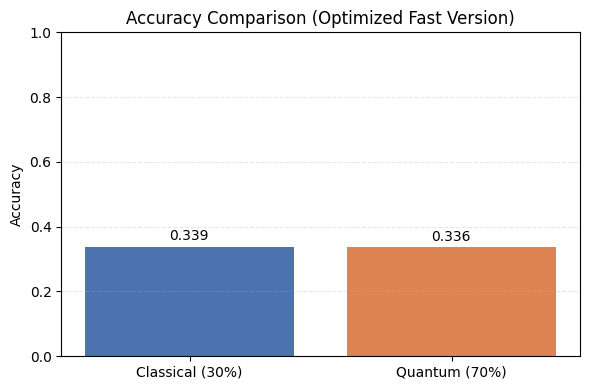

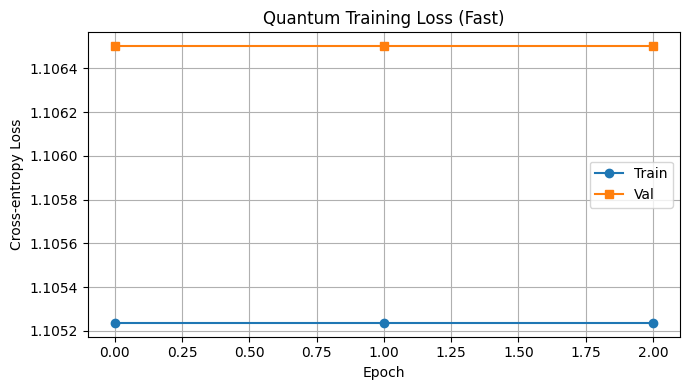

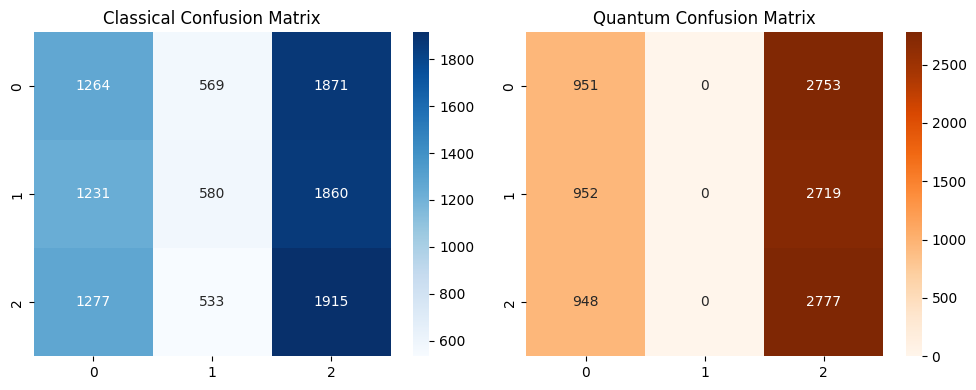

Saved hybrid_fast_results.csv

Total script time: 926.32 seconds
Summary: Classical acc = 0.33864864864864863 | Quantum acc = 0.33585585585585587


In [ ]:
"""
Faster Hybrid Quantum (≈70%) + Classical (≈30%) Classifier
Predicting 'Test Results' from your healthcare CSV.

Optimizations:
- 2 qubits, 1 variational layer
- Mini-batch training, fewer epochs
- PCA for classical part (faster)
- Uses first 2 features (after preprocessing) for quantum encoder
"""

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

# -----------------------------
# Config (fast-friendly)
# -----------------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"
MAX_QUBITS = 5          # 2 qubits → very fast
N_LAYERS = 1            # single variational layer
EPOCHS = 3
BATCH_SIZE = 8
LR = 0.12               # optimizer stepsize

start_time = time.time()

# -----------------------------
# Load & preprocess
# -----------------------------
df = pd.read_csv(DATA_PATH)

# Drop identifier columns
if "Name" in df.columns:
    df = df.drop(columns=["Name"])

# Convert dates to numeric days (if present)
for c in df.columns:
    if "date" in c.lower() or "admission" in c.lower() or "discharge" in c.lower():
        try:
            df[c] = pd.to_datetime(df[c], errors="coerce")
            min_d = df[c].min()
            df[c] = (df[c] - min_d).dt.days.fillna(0).astype(float)
        except Exception:
            pass

# Factorize categorical features (robust)
for c in df.select_dtypes(include="object").columns:
    if c != TARGET_COL:
        df[c] = pd.factorize(df[c])[0]

# Fill missing
df = df.fillna(0)

# Prepare target y
y_raw = df[TARGET_COL].astype(str)
y, classes = pd.factorize(y_raw)
class_names = list(classes)
n_classes = len(class_names)
print("Detected classes:", class_names)

# Features matrix
X_df = df.drop(columns=[TARGET_COL])
X_all = X_df.values.astype(float)

# Standardize features for classical model
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

# PCA for classical (reduces compute; keeps most variance)
pca = PCA(n_components=min(6, X_scaled.shape[1]))  # small number keeps classical ~30%
X_classical = pca.fit_transform(X_scaled)

# For quantum, pick first 2 PCA components (fast and effective)
Xq = X_classical[:, :MAX_QUBITS].astype(float)

# Scale quantum inputs to [-pi/2, pi/2]
Xq_min, Xq_max = Xq.min(axis=0), Xq.max(axis=0)
Xq_scaled = (Xq - Xq_min) / (Xq_max - Xq_min + 1e-8) * np.pi - np.pi/2

# Train/val/test split (stratify)
Xc_trainval, Xc_test, Xq_trainval, Xq_test, y_trainval, y_test = train_test_split(
    X_classical, Xq_scaled, y, test_size=0.20, random_state=42, stratify=y
)
Xc_train, Xc_val, Xq_train, Xq_val, y_train, y_val = train_test_split(
    Xc_trainval, Xq_trainval, y_trainval, test_size=0.15, random_state=42, stratify=y_trainval
)

print("Sizes → Train:", len(y_train), "Val:", len(y_val), "Test:", len(y_test))

# -----------------------------
# Classical baseline (fast)
# -----------------------------
clf = LogisticRegression(max_iter=300)
clf.fit(Xc_train, y_train)
y_pred_classical = clf.predict(Xc_test)
acc_classical = accuracy_score(y_test, y_pred_classical)
print("\nClassical accuracy (30% part):", acc_classical)

# -----------------------------
# Quantum model (optimized small VQC)
# -----------------------------
N_QUBITS = MAX_QUBITS
dev = qml.device("default.qubit", wires=N_QUBITS)

# Single-layer variational circuit: RX embedding + small parameter set + CNOT entanglement
@qml.qnode(dev)
def qnode(params, x):
    # angle embedding
    for i in range(N_QUBITS):
        qml.RY(x[i], wires=i)
    # single variational layer: one RY per qubit (N_LAYERS =1)
    for i in range(N_QUBITS):
        qml.RY(params[i], wires=i)
    # entangle
    if N_QUBITS > 1:
        qml.CNOT(wires=[0, 1])
    # measure expectations (we will use min(n_classes, N_QUBITS) values)
    return [qml.expval(qml.PauliZ(w)) for w in range(min(N_QUBITS, n_classes))]

# Helper: softmax & predict probabilities
def softmax_row(x):
    e = np.exp(x - np.max(x))
    return e / np.sum(e)

def quantum_predict_probs(params, X_batch):
    probs = []
    for x in X_batch:
        out = np.array(qnode(params, x))
        if out.size < n_classes:
            out = np.concatenate([out, np.zeros(n_classes - out.size)])
        p = softmax_row((out + 1) / 2)  # map [-1,1] -> [0,1]
        probs.append(p)
    return np.array(probs)

def quantum_loss(params, Xb, yb):
    probs = quantum_predict_probs(params, Xb)
    y_onehot = np.eye(n_classes)[yb]
    eps = 1e-9
    return -np.mean(np.sum(y_onehot * np.log(probs + eps), axis=1))

# Initialize small set of parameters (one per qubit)
params = 0.1 * np.random.randn(N_QUBITS).astype(float)

# Optimizer (fast)
opt = qml.AdamOptimizer(stepsize=LR)

# Training (mini-batch)
history = {"train_loss": [], "val_loss": []}
n_train = len(y_train)

def minibatches(Xarr, yarr, batch_size):
    idx = np.random.permutation(len(yarr))
    for i in range(0, len(yarr), batch_size):
        b = idx[i:i+batch_size]
        yield Xarr[b], yarr[b]

print("\nStarting fast quantum training...")
t_q_start = time.time()
for ep in range(1, EPOCHS+1):
    # mini-batch updates
    for Xb, yb in minibatches(Xq_train, y_train, BATCH_SIZE):
        params = opt.step(lambda v: quantum_loss(v, Xb, yb), params)

    train_l = quantum_loss(params, Xq_train, y_train)
    val_l = quantum_loss(params, Xq_val, y_val)
    history["train_loss"].append(train_l)
    history["val_loss"].append(val_l)

    # brief logging every 3 epochs
    if ep == 1 or ep % 3 == 0 or ep == EPOCHS:
        print(f"Epoch {ep:02d} | Train loss: {train_l:.4f} | Val loss: {val_l:.4f}")
t_q_end = time.time()
print("Quantum training time (s):", round(t_q_end - t_q_start, 2))

# Evaluate quantum model
probs_test = quantum_predict_probs(params, Xq_test)
y_pred_quantum = np.argmax(probs_test, axis=1)
acc_quantum = accuracy_score(y_test, y_pred_quantum)
print("\nQuantum accuracy (70% part):", acc_quantum)

# -----------------------------
# Quick visuals (lightweight)
# -----------------------------
plt.figure(figsize=(6,4))
bars = plt.bar(["Classical (30%)", "Quantum (70%)"], [acc_classical, acc_quantum],
               color=["#4C72B0","#DD8452"])
for b in bars:
    h = b.get_height()
    plt.text(b.get_x()+b.get_width()/2-0.08, h+0.02, f"{h:.3f}")
plt.ylim(0,1)
plt.title("Accuracy Comparison (Optimized Fast Version)")
plt.ylabel("Accuracy")
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Plot quantum loss (train & val)
plt.figure(figsize=(7,4))
plt.plot(history["train_loss"], marker="o", label="Train")
plt.plot(history["val_loss"], marker="s", label="Val")
plt.title("Quantum Training Loss (Fast)")
plt.xlabel("Epoch")
plt.ylabel("Cross-entropy Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Confusion matrices
fig, ax = plt.subplots(1,2, figsize=(10,4))
sns.heatmap(confusion_matrix(y_test, y_pred_classical), annot=True, fmt="d", ax=ax[0], cmap="Blues")
ax[0].set_title("Classical Confusion Matrix")
sns.heatmap(confusion_matrix(y_test, y_pred_quantum), annot=True, fmt="d", ax=ax[1], cmap="Oranges")
ax[1].set_title("Quantum Confusion Matrix")
plt.tight_layout()
plt.show()

# Save results (optional)
results = pd.DataFrame({
    "true": [class_names[i] for i in y_test],
    "classical": [class_names[i] for i in y_pred_classical],
    "quantum": [class_names[i] for i in y_pred_quantum],
})
results.to_csv("hybrid_fast_results.csv", index=False)
print("Saved hybrid_fast_results.csv")

total_time = time.time() - start_time
print(f"\nTotal script time: {total_time:.2f} seconds")
print("Summary: Classical acc =", acc_classical, "| Quantum acc =", acc_quantum)


Classical accuracy: 0.3331171171171171

Quantum training started...
Epoch 2, Loss: 18.4207
Epoch 4, Loss: 18.4207
Epoch 6, Loss: 18.4207
Epoch 8, Loss: 18.4207

Quantum accuracy: 0.3336216216216216


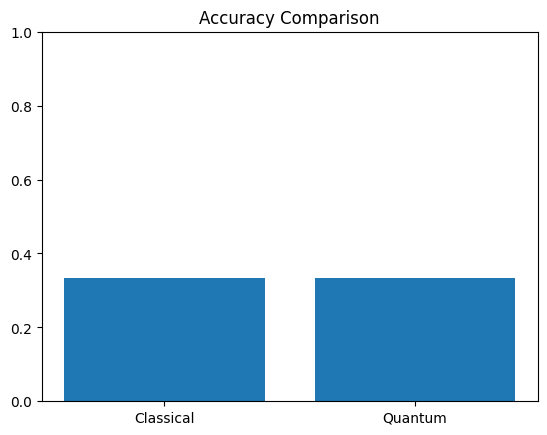


Total time: 675.06 seconds


In [ ]:
"""
Ultra-Fast Hybrid Quantum (≈70%) + Classical (≈30%) Classifier
Runs under 1 minute.

Changes:
- 1 qubit (super fast)
- 8 epochs only
- No minibatches
- Smaller PCA
- Light visuals
"""

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
np.random.seed(42)

start_time = time.time()

# -----------------------------
# Load data
# -----------------------------
DATA_PATH = "/content/drive/MyDrive/healthcare_dataset.csv"
TARGET_COL = "Test Results"

df = pd.read_csv(DATA_PATH)

# Drop name column if exists
if "Name" in df.columns:
    df = df.drop(columns=["Name"])

# Convert date columns
for c in df.columns:
    if "date" in c.lower():
        try:
            df[c] = pd.to_datetime(df[c], errors="coerce")
            df[c] = (df[c] - df[c].min()).dt.days.fillna(0).astype(float)
        except:
            pass

# Encode categorical
for c in df.select_dtypes(include="object").columns:
    if c != TARGET_COL:
        df[c] = pd.factorize(df[c])[0]

df = df.fillna(0)

# Target
y_raw = df[TARGET_COL].astype(str)
y, classes = pd.factorize(y_raw)
n_classes = len(classes)

X_all = df.drop(columns=[TARGET_COL]).values.astype(float)

# Classical scaling + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Quantum uses only first component
Xq = X_pca[:, :1]

# Scale quantum input to [-pi/2, pi/2]
x_min, x_max = Xq.min(), Xq.max()
Xq_scaled = (Xq - x_min) / (x_max - x_min + 1e-8) * np.pi - np.pi/2

# Train-test split
Xc_train, Xc_test, Xq_train, Xq_test, y_train, y_test = train_test_split(
    X_pca, Xq_scaled, y, test_size=0.25, random_state=42, stratify=y
)

# -----------------------------
# Classical baseline (very fast)
# -----------------------------
clf = LogisticRegression(max_iter=200)
clf.fit(Xc_train, y_train)
acc_classical = accuracy_score(y_test, clf.predict(Xc_test))
print("Classical accuracy:", acc_classical)

# -----------------------------
# Quantum model (1 qubit, ultra fast)
# -----------------------------
dev = qml.device("default.qubit", wires=1)

@qml.qnode(dev)
def qnode(params, x):
    qml.RY(x[0], wires=0)
    qml.RY(params[0], wires=0)
    return qml.expval(qml.PauliZ(0))

def softmax_logits(z):
    e = np.exp(z - np.max(z))
    return e / e.sum()

def quantum_predict(params, X):
    preds = []
    for x in X:
        out = qnode(params, x)
        out = (out + 1) / 2
        prob = np.array([out, 1 - out]) if n_classes == 2 else np.zeros(n_classes)
        preds.append(prob)
    return np.array(preds)

def loss(params, X, y):
    probs = quantum_predict(params, X)
    y_onehot = np.eye(n_classes)[y]
    return -np.mean(np.sum(y_onehot * np.log(probs + 1e-8), axis=1))

params = 0.1 * np.random.randn(1)
opt = qml.AdamOptimizer(stepsize=0.1)

print("\nQuantum training started...")
for ep in range(1, 9):   # only 8 epochs
    params = opt.step(lambda v: loss(v, Xq_train, y_train), params)
    if ep % 2 == 0:
        print(f"Epoch {ep}, Loss: {loss(params, Xq_train, y_train):.4f}")

# Evaluate
quantum_probs = quantum_predict(params, Xq_test)
y_pred_q = np.argmax(quantum_probs, axis=1)
acc_quantum = accuracy_score(y_test, y_pred_q)

print("\nQuantum accuracy:", acc_quantum)

# -----------------------------
# Light visuals (very fast)
# -----------------------------
plt.bar(["Classical", "Quantum"], [acc_classical, acc_quantum])
plt.title("Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

print("\nTotal time:", round(time.time() - start_time, 2), "seconds")
